In [77]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [78]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

In [79]:
import shlex

def _parse_flag(command, flag):
    """Extract the value of --flag from a command string. Returns None if absent."""
    parts = shlex.split(command)
    for i, p in enumerate(parts):
        if p == flag and i + 1 < len(parts):
            return parts[i + 1]
    return None


def load_run(log_path):
    """Parse a single task .out file → (config dict, list of eval dicts).

    Enriches config with 'lr' (from first eval event) and
    'lora_plus_multiplier' (from command string) since these aren't
    present in the config JSON event.
    """
    config, evals = None, []
    for line in Path(log_path).read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
        except json.JSONDecodeError:
            continue
        if obj.get("event") == "config":
            config = obj
        elif obj.get("event") == "eval":
            evals.append(obj)
    if config is not None and evals:
        config.setdefault("lr", evals[0]["lr"])
        lp = _parse_flag(config["command"], "--lora_plus_multiplier")
        config.setdefault("lora_plus_multiplier", float(lp) if lp else 1.0)
    return config, evals


def load_sweep(group):
    """Load all runs for a sweep group. Returns list of (config, evals) tuples."""
    log_dir = Path(f"../logs/{group}/run_info/logs")
    runs = []
    for f in sorted(log_dir.glob("*.out")):
        config, evals = load_run(f)
        if config is not None and evals:
            runs.append((config, evals))
    return runs

## LoRA+ (η, m) co-sweep — AdamW, r=16, 1 epoch

In [ ]:
# Merge LoRA+ runs across all sweeps that swept η × m for AdamW.
# - loraplus_lowlr_2k    : adamw × m ∈ {4, 16} × η ∈ {1e-5, 3e-5}
# - loraplus_2k_1ep      : adamw × m ∈ {1, 4, 16} × η ∈ {1e-4, 3e-4}
# - lr_sweep_2k          : adamw × m=1     × η ∈ {3e-5..1e-3} (and other optims)
# - optim_compare_high_eta_2k : adamw × m=1 × η ∈ {3e-3, 1e-2}
# - new_optimizers_2k    : adamw × m=1     × η ∈ {3e-5..1e-3} (other optims too)
# Filter to optimizer="adamw" only. Dedup by (m, η).
LP_SOURCES = (
    "loraplus_lowlr_2k",
    "loraplus_2k_1ep",
    "lr_sweep_2k",
    "optim_compare_high_eta_2k",
    "new_optimizers_2k",
)

lp_runs, _seen = [], set()
for group in LP_SOURCES:
    if not _has_runs(group):
        continue
    for cfg, evs in load_sweep(group):
        if cfg.get("optimizer") != "adamw":
            continue
        m = float(cfg.get("lora_plus_multiplier", 1.0))
        key = (m, float(cfg["lr"]))
        if key in _seen:
            continue
        _seen.add(key)
        lp_runs.append((cfg, evs))

print(f"Loaded {len(lp_runs)} AdamW LoRA+ runs (merged)")
for cfg, evs in sorted(lp_runs, key=lambda x: (x[0].get("lora_plus_multiplier", 1), x[0]["lr"])):
    lr = cfg["lr"]
    m = cfg.get("lora_plus_multiplier", 1.0)
    print(f"  η={lr:.0e}  m={m:.0f}  final={evs[-1]['eval_loss']:.4f}")

In [ ]:
M_COLORS = {1: plt.cm.plasma(0.15), 4: plt.cm.plasma(0.50), 16: plt.cm.plasma(0.85)}

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# Left: η vs final eval loss (one line per multiplier m)
ax = axes[0]
ms = sorted({int(round(c.get("lora_plus_multiplier", 1.0))) for c, _ in lp_runs})
for m in ms:
    rows = sorted([(c["lr"], e[-1]["eval_loss"]) for c, e in lp_runs
                   if int(round(c.get("lora_plus_multiplier", 1.0))) == m])
    if rows:
        ax.plot([r[0] for r in rows], [r[1] for r in rows],
                color=M_COLORS.get(m, "grey"), marker="o", label=f"m={m}")
ax.set_xscale("log")
ax.set_xlabel("η (log)"); ax.set_ylabel("Final eval loss")
ax.grid(True, alpha=0.3, which="both")
ax.set_title("Final eval loss vs η, per m")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=True)

# Right: best η per m, training curves
ax = axes[1]
best_per_m = {}
for cfg, evs in lp_runs:
    m = int(round(cfg.get("lora_plus_multiplier", 1.0)))
    fl = evs[-1]["eval_loss"]
    if m not in best_per_m or fl < best_per_m[m][2]:
        best_per_m[m] = (cfg, evs, fl)
for m, (cfg, evs, fl) in sorted(best_per_m.items()):
    ax.plot([e["step"] for e in evs], [e["eval_loss"] for e in evs],
            color=M_COLORS.get(m, "grey"), marker="o", markersize=4,
            label=f"m={m} (η={cfg['lr']:.0e}, final={fl:.4f})")
ax.set_xlabel("Step"); ax.set_ylabel("Eval loss")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax.set_title("Best η per m — training curves")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=True)

fig.suptitle("LoRA+ (η, m) — AdamW, r=16, 1 epoch")
fig.tight_layout()
plt.show()

## All optimizers — η sweep, r=16, 2000 steps

η ∈ {3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2}, seed=0. All optimizers compared on the
same axis. Sources merged across `lr_sweep_2k`, `optim_compare_high_eta_2k`,
`muon_lowlr_2k`, `new_optimizers_high_eta_2k`, `new_optimizers_2k`, `psi_lora_2k`,
`galore_fixed_2k`. Diverged runs (max eval > 1.5) filtered.

**Honest naming.** What we previously called `psi-lora` was just diagonal D_V/D_U scaling —
renamed to **`diag-scaled-lora`**. `kfac-lora` was a custom variant (r×r gradient outer
products) — renamed to **`kron-grad-lora`**. The `psi-lora` slot now points to the paper
Algorithm 3 port (F-LoRSUM proximal subspace iteration with K-FAC metrics + low-rank
momentum, eq. 14 of arXiv 2602.16456).

**Muon-LoRA NS bug fix.** Original `_newton_schulz` re-multiplied output by input Frobenius
norm, breaking scale-invariance — combined with PEFT's B=0 init the updates collapsed and
η was nearly irrelevant. Fixed: NS output now has Frobenius norm √r regardless of input.

**GaLore** (`galore-adamw`) uses a different training mode — full dense weights with rank-r
gradient projection refreshed every 200 steps. Included for direct comparison; it's ~3× slower
per step than LoRA-mode optimizers due to backprop through full weights.

In [82]:
OPTIM_COLORS = {
    "adamw":            "#1f77b4",
    "scaled-lora":      "#ff7f0e",
    "lin-lora":         "#2ca02c",
    "adam-scaled-lora": "#d62728",
    "adam-lin-lora":    "#9467bd",
    "muon-lora":        "#e377c2",
    "diag-scaled-lora": "#17becf",
    "kron-grad-lora":   "#bcbd22",
    "psi-lora":         "#8c564b",
    "galore-adamw":     "#7f7f7f",
}


def _has_runs(group):
    """True if the group has at least one populated .out file."""
    log_dir = Path(f"../logs/{group}/run_info/logs")
    if not log_dir.exists():
        return False
    return any(f.stat().st_size > 0 for f in log_dir.glob("*.out"))


def _max_loss(evs):
    return max(e["eval_loss"] for e in evs)


# Sources, in priority order for (optimizer, η) deduplication.
# Earlier groups override later groups.
#   psi_lora_2k           — Algorithm 3 port (F-LoRSUM + LR momentum)
#   muon_lowlr_2k         — bug-fixed muon at low η
#   boundary_extend3_2k   — lin/scaled at η ∈ {10, 30}
#   boundary_extend2_2k   — diag/lin/scaled at η ∈ {1, 3}
#   boundary_extend_2k    — diag/lin/scaled at η ∈ {3e-2, 1e-1, 3e-1}
#   new_optimizers_high_eta_2k — diag/kron/muon at η ∈ {3e-3,1e-2,3e-2}
#   new_optimizers_2k     — original (diag/kron at low η; pre-fix muon — superseded)
#   galore_fixed_2k       — GaLore rewritten to match official ~/GaLore
#   galore_2k             — GaLore buggy original (superseded)
#   optim_compare_high_eta_2k — original 5 optimizers at η ∈ {3e-3, 1e-2}
#   lr_sweep_2k           — original 5 optimizers at low η
SOURCE_GROUPS = (
    "psi_lora_2k",
    "muon_lowlr_2k",
    "boundary_extend3_2k",
    "boundary_extend2_2k",
    "boundary_extend_2k",
    "new_optimizers_high_eta_2k",
    "galore_fixed_2k",
    "optim_compare_high_eta_2k",
    "lr_sweep_2k",
    "new_optimizers_2k",
    "galore_2k",
)
RENAME_ALIAS = {  # legacy log group → honest label
    "psi-lora":  "diag-scaled-lora",  # only applied to legacy groups (see NEW_PSI_GROUPS below)
    "kfac-lora": "kron-grad-lora",
}
NEW_PSI_GROUPS = {"psi_lora_2k"}

all_runs, seen = [], set()
for group in SOURCE_GROUPS:
    if not _has_runs(group):
        continue
    for cfg, evs in load_sweep(group):
        if group not in NEW_PSI_GROUPS:
            cfg["optimizer"] = RENAME_ALIAS.get(cfg["optimizer"], cfg["optimizer"])
        opt = cfg["optimizer"]
        if opt not in OPTIM_COLORS:
            continue
        key = (opt, float(cfg["lr"]))
        if key in seen:
            continue
        seen.add(key)
        all_runs.append((cfg, evs))

print(f"Loaded {len(all_runs)} runs across {len({c['optimizer'] for c, _ in all_runs})} optimizers")
for cfg, evs in sorted(all_runs, key=lambda x: (x[0]["optimizer"], x[0]["lr"])):
    flag = "DIVERGED" if _max_loss(evs) >= 1.5 else ""
    print(f"  {cfg['optimizer']:<18s}  η={cfg['lr']:.0e}  step={evs[-1]['step']}  "
          f"final={evs[-1]['eval_loss']:.4f}  {flag}")

Loaded 77 runs across 10 optimizers
  adam-lin-lora       η=3e-05  step=2000  final=0.8426  
  adam-lin-lora       η=1e-04  step=2000  final=0.8032  
  adam-lin-lora       η=3e-04  step=2000  final=0.7723  
  adam-lin-lora       η=1e-03  step=2000  final=0.7564  
  adam-lin-lora       η=3e-03  step=2000  final=0.8139  
  adam-lin-lora       η=1e-02  step=2000  final=1.3112  
  adam-scaled-lora    η=3e-05  step=2000  final=0.8401  
  adam-scaled-lora    η=1e-04  step=2000  final=0.8002  
  adam-scaled-lora    η=3e-04  step=2000  final=0.7702  
  adam-scaled-lora    η=1e-03  step=2000  final=0.7572  
  adam-scaled-lora    η=3e-03  step=2000  final=0.8235  
  adam-scaled-lora    η=1e-02  step=2000  final=1.6646  DIVERGED
  adamw               η=3e-05  step=2000  final=0.8088  
  adamw               η=1e-04  step=2000  final=0.7795  
  adamw               η=3e-04  step=2000  final=0.7579  
  adamw               η=1e-03  step=2000  final=0.7875  
  adamw               η=3e-03  step=2000  fi

In [ ]:
DIVERGE_THRESHOLD = 1.5

keep = [(c, e) for c, e in all_runs if _max_loss(e) < DIVERGE_THRESHOLD]
drop = [(c, e) for c, e in all_runs if _max_loss(e) >= DIVERGE_THRESHOLD]
for cfg, evs in sorted(drop, key=lambda x: (x[0]["optimizer"], x[0]["lr"])):
    print(f"  [filtered diverged] {cfg['optimizer']:<18s} η={cfg['lr']:.0e} "
          f"max={_max_loss(evs):.3f} final={evs[-1]['eval_loss']:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: η vs final eval loss (one line per optimizer)
ax = axes[0]
opts = sorted({c["optimizer"] for c, _ in keep})
for opt in opts:
    rows = sorted([(c["lr"], e[-1]["eval_loss"]) for c, e in keep
                   if c["optimizer"] == opt])
    if rows:
        ax.plot([r[0] for r in rows], [r[1] for r in rows],
                color=OPTIM_COLORS.get(opt, "grey"),
                marker="o", lw=1.5, label=opt)
ax.set_xscale("log")
ax.set_xlabel("η (log)"); ax.set_ylabel("Final eval loss")
ax.grid(True, alpha=0.3, which="both")
ax.set_title("Final eval loss vs η, per optimizer")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=True)

# Right: best η per optimizer — training curves
ax = axes[1]
best_per_opt = {}
for cfg, evs in keep:
    opt = cfg["optimizer"]
    fl = evs[-1]["eval_loss"]
    if opt not in best_per_opt or fl < best_per_opt[opt][2]:
        best_per_opt[opt] = (cfg, evs, fl)
for opt, (cfg, evs, fl) in sorted(best_per_opt.items(), key=lambda kv: kv[1][2]):
    ax.plot([e["step"] for e in evs], [e["eval_loss"] for e in evs],
            color=OPTIM_COLORS.get(opt, "grey"),
            marker="o", markersize=3, lw=1.5,
            label=f"{opt} (η={cfg['lr']:.0e}, final={fl:.4f})")
ax.set_xlabel("Step"); ax.set_ylabel("Eval loss")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax.set_title("Best η per optimizer — training curves")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=True)

fig.suptitle(f"All optimizers — η sweep, r=16, 2000 steps "
             f"(max eval > {DIVERGE_THRESHOLD} filtered: {len(drop)} runs)")
fig.tight_layout()
plt.show()

## SVD oracle — step vs cumulative, η sweep, r=16, 1 epoch

`svd_step_oracle`: each AdamW step projected to rank r via randomized SVD (niter=4).  
`svd_cumulative_oracle`: cumulative displacement from init projected to rank r.  
Both use full dense weights (not LoRA adapters). Reference: best AdamW LoRA at η=3e-4.

In [84]:
svd_runs = load_sweep("svd_sweep_2k_1ep")
print(f"Loaded {len(svd_runs)} SVD oracle runs")
for cfg, evs in sorted(svd_runs, key=lambda x: (x[0]["training_mode"], x[0]["lr"])):
    mode = cfg["training_mode"]
    lr = cfg["lr"]
    proj = cfg.get("svd_projection", "?")
    last = evs[-1]["step"]
    el = evs[-1]["eval_loss"]
    print(f"  {mode:<25s}  η={lr:.0e}  {proj}  steps through {last}  eval_loss={el:.4f}")

Loaded 8 SVD oracle runs
  svd_cumulative_oracle      η=3e-05  randomized_niter4  steps through 2000  eval_loss=0.8065
  svd_cumulative_oracle      η=1e-04  randomized_niter4  steps through 2000  eval_loss=0.7869
  svd_cumulative_oracle      η=3e-04  randomized_niter4  steps through 2000  eval_loss=0.9734
  svd_cumulative_oracle      η=1e-03  randomized_niter4  steps through 2000  eval_loss=3.8249
  svd_step_oracle            η=3e-05  randomized_niter4  steps through 2000  eval_loss=0.8773
  svd_step_oracle            η=1e-04  randomized_niter4  steps through 2000  eval_loss=0.8053
  svd_step_oracle            η=3e-04  randomized_niter4  steps through 2000  eval_loss=0.8139
  svd_step_oracle            η=1e-03  randomized_niter4  steps through 2000  eval_loss=2.6889


  [filtered diverged] svd_cumulative_oracle  η=1e-03  max=4.921  final=3.8249
  [filtered diverged] svd_step_oracle  η=1e-03  max=4.947  final=2.6889


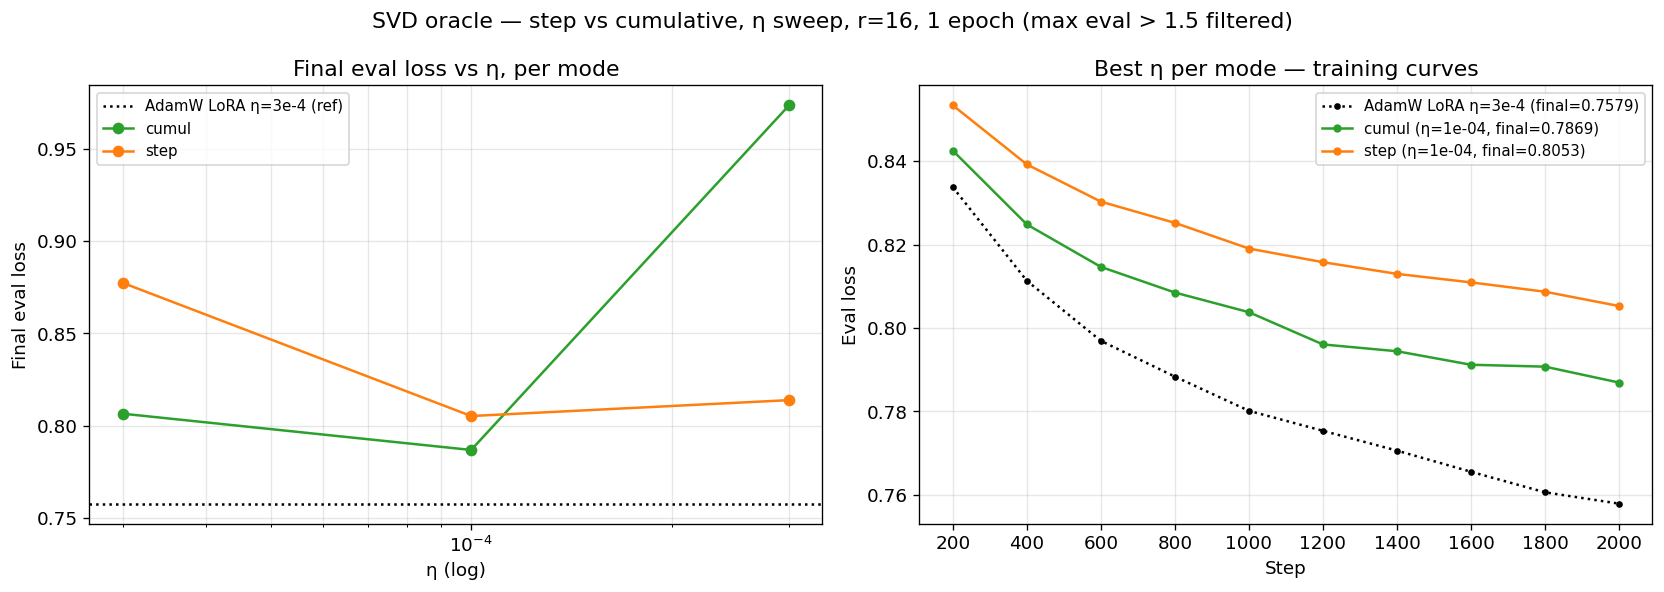

In [85]:
DIVERGE_THRESHOLD = 1.5
MODE_COLORS = {"svd_step_oracle": "#ff7f0e", "svd_cumulative_oracle": "#2ca02c"}

if not svd_runs:
    print("No SVD oracle results yet — rerun after svd_sweep_2k_1ep completes.")
else:
    converged = [(c, e) for c, e in svd_runs if _max_loss(e) < DIVERGE_THRESHOLD]
    diverged  = [(c, e) for c, e in svd_runs if _max_loss(e) >= DIVERGE_THRESHOLD]
    for cfg, evs in sorted(diverged, key=lambda x: (x[0]["training_mode"], x[0]["lr"])):
        print(f"  [filtered diverged] {cfg['training_mode']}  η={cfg['lr']:.0e}  "
              f"max={_max_loss(evs):.3f}  final={evs[-1]['eval_loss']:.4f}")

    # Adamw LoRA reference: best entry from the full optimizer sweep
    adamw_ref_run = None
    for cfg, evs in keep:
        if cfg["optimizer"] == "adamw" and abs(cfg["lr"] - 3e-4) < 1e-9:
            adamw_ref_run = (cfg, evs); break

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: η vs final eval loss (one line per mode)
    ax = axes[0]
    if adamw_ref_run is not None:
        ax.axhline(adamw_ref_run[1][-1]["eval_loss"], color="black", ls=":",
                   lw=1.5, label="AdamW LoRA η=3e-4 (ref)")
    modes = sorted({c["training_mode"] for c, _ in converged})
    for mode in modes:
        rows = sorted([(c["lr"], e[-1]["eval_loss"]) for c, e in converged
                       if c["training_mode"] == mode])
        if rows:
            short = "step" if "step" in mode else "cumul"
            ax.plot([r[0] for r in rows], [r[1] for r in rows],
                    color=MODE_COLORS.get(mode, "grey"),
                    marker="o", lw=1.5, label=short)
    ax.set_xscale("log")
    ax.set_xlabel("η (log)"); ax.set_ylabel("Final eval loss")
    ax.grid(True, alpha=0.3, which="both")
    ax.set_title("Final eval loss vs η, per mode")
    ax.legend(fontsize=9)

    # Right: best η per mode — training curves
    ax = axes[1]
    if adamw_ref_run is not None:
        cfg, evs = adamw_ref_run
        ax.plot([e["step"] for e in evs], [e["eval_loss"] for e in evs],
                color="black", lw=1.5, ls=":", marker="o", markersize=3,
                label=f"AdamW LoRA η=3e-4 (final={evs[-1]['eval_loss']:.4f})")
    best_per_mode = {}
    for cfg, evs in converged:
        mode = cfg["training_mode"]
        fl = evs[-1]["eval_loss"]
        if mode not in best_per_mode or fl < best_per_mode[mode][2]:
            best_per_mode[mode] = (cfg, evs, fl)
    for mode, (cfg, evs, fl) in sorted(best_per_mode.items()):
        short = "step" if "step" in mode else "cumul"
        ax.plot([e["step"] for e in evs], [e["eval_loss"] for e in evs],
                color=MODE_COLORS.get(mode, "grey"),
                marker="o", markersize=4,
                label=f"{short} (η={cfg['lr']:.0e}, final={fl:.4f})")
    ax.set_xlabel("Step"); ax.set_ylabel("Eval loss")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
    ax.set_title("Best η per mode — training curves")
    ax.legend(fontsize=9)

    fig.suptitle(f"SVD oracle — step vs cumulative, η sweep, r=16, 1 epoch "
                 f"(max eval > {DIVERGE_THRESHOLD} filtered)")
    fig.tight_layout()
    plt.show()

## Muon-LoRA variants — beat AdamW campaign

Hypothesis-driven sweep:
- **Tier 1 (`muon_loraplus_2k`)**: H1 — LoRA+ asymmetry on B's lr (m ∈ {4, 16}). Baseline m=1 reused from earlier groups.
- **Tier 2 (`muon_nsoff_2k`)**: H3 sanity — `--muon_ns_steps 0` ⇒ momentum SGD (NS disabled). If matches Muon-LoRA, the orthogonalization is irrelevant.
- **Tier 3 (`product_muon_2k`)**: H2 — `ProductMuonLoRA`, NS on the merged-direction proxy `D = (1/scale)·m_B·(AAᵀ+δI)⁻¹·A` then Sylvester-recovered. Theory: `docs/theory/main.tex` line 622+.
- **Tier 4 (`adam_muon_2k`)**: H4 — `AdamMuonLoRA`, NS on Adam's m̂/(√v̂+ε) direction.

Reference frontiers (from earlier sweeps): AdamW @ 0.7579, adam-lin-lora @ 0.7564. Goal: **strictly beat** both.

In [86]:
def _parse_muon_ns_steps(cfg):
    """Pull --muon_ns_steps from command string; defaults to 5."""
    v = _parse_flag(cfg["command"], "--muon_ns_steps")
    return int(v) if v is not None else 5


def load_muon_runs():
    """Aggregate all Muon-family runs across the campaign + earlier groups for the m=1 baseline.
    Returns list of (cfg, evs) with cfg['lora_plus_multiplier'] and cfg['muon_ns_steps']
    populated. (optimizer, lr, m, ns_steps) is the dedup key."""
    sources = (
        "muon_loraplus_2k",            # Tier 1: m ∈ {4, 16}
        "muon_nsoff_2k",               # Tier 2: ns_steps=0
        "product_muon_2k",             # Tier 3
        "adam_muon_2k",                # Tier 4
        # Pre-existing m=1, ns_steps=5 muon-lora runs:
        "muon_lowlr_2k",               # η ∈ {3e-5..1e-3}
        "new_optimizers_high_eta_2k",  # η ∈ {3e-3..3e-2}
    )
    runs, seen = [], set()
    for group in sources:
        if not _has_runs(group):
            continue
        for cfg, evs in load_sweep(group):
            opt = cfg["optimizer"]
            if opt not in {"muon-lora", "product-muon-lora", "adam-muon-lora"}:
                continue
            cfg["muon_ns_steps"] = _parse_muon_ns_steps(cfg)
            m = float(cfg.get("lora_plus_multiplier", 1.0))
            key = (opt, float(cfg["lr"]), m, cfg["muon_ns_steps"])
            if key in seen:
                continue
            seen.add(key)
            cfg["_source_group"] = group
            runs.append((cfg, evs))
    return runs


muon_runs = load_muon_runs()
print(f"Loaded {len(muon_runs)} Muon-family runs")
for cfg, evs in sorted(muon_runs, key=lambda x: (x[0]["optimizer"], x[0]["muon_ns_steps"],
                                                  x[0]["lora_plus_multiplier"], x[0]["lr"])):
    flag = "DIVERGED" if _max_loss(evs) >= 1.5 else ""
    print(f"  {cfg['optimizer']:<18s}  η={cfg['lr']:.0e}  m={float(cfg['lora_plus_multiplier']):>4.1f}  "
          f"ns={cfg['muon_ns_steps']}  step={evs[-1]['step']}  final={evs[-1]['eval_loss']:.4f}  {flag}")

Loaded 17 Muon-family runs
  muon-lora           η=3e-04  m= 1.0  ns=0  step=2000  final=1.1844  
  muon-lora           η=1e-03  m= 1.0  ns=0  step=2000  final=1.1658  
  muon-lora           η=3e-03  m= 1.0  ns=0  step=2000  final=1.0672  
  muon-lora           η=1e-02  m= 1.0  ns=0  step=2000  final=0.9499  
  muon-lora           η=3e-05  m= 1.0  ns=5  step=2000  final=1.0015  
  muon-lora           η=1e-04  m= 1.0  ns=5  step=2000  final=0.8842  
  muon-lora           η=3e-04  m= 1.0  ns=5  step=2000  final=0.8291  
  muon-lora           η=1e-03  m= 1.0  ns=5  step=2000  final=0.7873  
  muon-lora           η=3e-03  m= 1.0  ns=5  step=2000  final=0.7675  
  muon-lora           η=1e-02  m= 1.0  ns=5  step=2000  final=0.8144  
  muon-lora           η=3e-02  m= 1.0  ns=5  step=2000  final=1.1452  
  muon-lora           η=1e-03  m= 4.0  ns=5  step=2000  final=0.7674  
  muon-lora           η=3e-03  m= 4.0  ns=5  step=2000  final=0.7759  
  muon-lora           η=1e-02  m= 4.0  ns=5  step=

In [ ]:
DIVERGE_THRESHOLD_M = 1.5
muon_keep = [(c, e) for c, e in muon_runs if _max_loss(e) < DIVERGE_THRESHOLD_M]


def _variant_label(cfg):
    opt = cfg["optimizer"]
    m = float(cfg.get("lora_plus_multiplier", 1.0))
    ns = cfg["muon_ns_steps"]
    base = {"muon-lora": "muon", "product-muon-lora": "product-muon",
            "adam-muon-lora": "adam-muon"}[opt]
    parts = [base]
    if m != 1.0:
        parts.append(f"m={int(m)}")
    if ns == 0:
        parts.append("ns=0")
    return "+".join(parts)


VARIANT_COLORS = {
    "muon":              "#e377c2",
    "muon+m=4":          "#d62728",
    "muon+m=16":         "#8c2d04",
    "muon+ns=0":         "#bababa",
    "product-muon":      "#1f77b4",
    "product-muon+m=4":  "#0d3d66",
    "adam-muon":         "#2ca02c",
    "adam-muon+m=4":     "#0d4f0d",
}

# Reference frontiers from the all-optimizer sweep (cell 17abee59).
ADAMW_REF = None
ADAMLIN_REF = None
for cfg, evs in keep:
    fl = evs[-1]["eval_loss"]
    if cfg["optimizer"] == "adamw" and (ADAMW_REF is None or fl < ADAMW_REF[1][-1]["eval_loss"]):
        ADAMW_REF = (cfg, evs)
    if cfg["optimizer"] == "adam-lin-lora" and (ADAMLIN_REF is None or fl < ADAMLIN_REF[1][-1]["eval_loss"]):
        ADAMLIN_REF = (cfg, evs)

# Wider canvas to leave room for side legends
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: η vs final eval loss, one line per variant
ax = axes[0]
if ADAMW_REF is not None:
    ax.axhline(ADAMW_REF[1][-1]["eval_loss"], color="black", ls=":", lw=1.5,
               label=f"AdamW best ({ADAMW_REF[1][-1]['eval_loss']:.4f})")
if ADAMLIN_REF is not None:
    ax.axhline(ADAMLIN_REF[1][-1]["eval_loss"], color="purple", ls=":", lw=1.5,
               label=f"adam-lin-lora best ({ADAMLIN_REF[1][-1]['eval_loss']:.4f})")

variants = sorted({_variant_label(c) for c, _ in muon_keep})
for v in variants:
    rows = sorted([(c["lr"], e[-1]["eval_loss"]) for c, e in muon_keep
                   if _variant_label(c) == v])
    if rows:
        ax.plot([r[0] for r in rows], [r[1] for r in rows],
                color=VARIANT_COLORS.get(v, "grey"),
                marker="o", lw=1.5, label=v)
ax.set_xscale("log")
ax.set_xlabel("η (log)"); ax.set_ylabel("Final eval loss")
ax.grid(True, alpha=0.3, which="both")
ax.set_title("Muon variants — final eval loss vs η")
# Legend outside the axes (right side) so it can't cover data points.
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=7, frameon=True)

# Right: best η per variant — training curves
ax = axes[1]
if ADAMW_REF is not None:
    cfg, evs = ADAMW_REF
    ax.plot([e["step"] for e in evs], [e["eval_loss"] for e in evs],
            color="black", lw=1.5, ls=":", label=f"AdamW (final={evs[-1]['eval_loss']:.4f})")
if ADAMLIN_REF is not None:
    cfg, evs = ADAMLIN_REF
    ax.plot([e["step"] for e in evs], [e["eval_loss"] for e in evs],
            color="purple", lw=1.5, ls=":", label=f"adam-lin-lora (final={evs[-1]['eval_loss']:.4f})")
best_per_variant = {}
for cfg, evs in muon_keep:
    v = _variant_label(cfg)
    fl = evs[-1]["eval_loss"]
    if v not in best_per_variant or fl < best_per_variant[v][2]:
        best_per_variant[v] = (cfg, evs, fl)
for v, (cfg, evs, fl) in sorted(best_per_variant.items(), key=lambda kv: kv[1][2]):
    ax.plot([e["step"] for e in evs], [e["eval_loss"] for e in evs],
            color=VARIANT_COLORS.get(v, "grey"),
            marker="o", markersize=3, lw=1.5,
            label=f"{v} (η={cfg['lr']:.0e}, final={fl:.4f})")
ax.set_xlabel("Step"); ax.set_ylabel("Eval loss")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax.set_title("Muon variants — best η training curves")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=7, frameon=True)

fig.suptitle(f"Muon-LoRA campaign — {len(muon_keep)}/{len(muon_runs)} converged "
             f"(>{DIVERGE_THRESHOLD_M} filtered)")
fig.tight_layout()
plt.show()

# Verdict table
print("\n=== Did we beat AdamW? ===")
adamw_floor = ADAMW_REF[1][-1]["eval_loss"] if ADAMW_REF else float("inf")
adamlin_floor = ADAMLIN_REF[1][-1]["eval_loss"] if ADAMLIN_REF else float("inf")
for v, (cfg, evs, fl) in sorted(best_per_variant.items(), key=lambda kv: kv[1][2]):
    beat_adamw = "✅" if fl < adamw_floor else "❌"
    beat_adamlin = "✅" if fl < adamlin_floor else "❌"
    print(f"  {v:<22s}  best={fl:.4f}  vs AdamW({adamw_floor:.4f}): {beat_adamw}  "
          f"vs adam-lin({adamlin_floor:.4f}): {beat_adamlin}")

## H4 *-Post + H5 matrix-Adam + Polar-Product investigation

Cross-investigation leaderboard for the lin/scaled-lora extensions:
- **`*-post`**: Adam(m,v) on raw ∇, then geometric solve (Sylvester / Gram) on Adam's step. RMS-aligned step magnitude.
- **`*-matrix`**: per-pair scalar v̂ instead of per-coord — preserves direction by sacrificing Adam's per-coord adaptation.
- **`adam-polar-product-lora`**: theory's closed-form spectral-product update (lemma at `docs/theory/main.tex` line 622-660). Polar (NS) sandwiched between two factors of S^{-1/2}, fed Adam's denoised direction.

See `docs/notes/optimizer_synthesis.md` for the cross-investigation synthesis.

In [ ]:
# Load all post-Adam and polar-product sweep groups
ext_groups = [
    "h4_post_2k", "h4_post_rmsalign_2k",
    "h5_matrix_2k", "h5_matrix_r64_2k",
    "polar_product_2k",
    "h3_rsweep_2k",                           # for r-scan baselines
    "optim_compare_high_eta_2k", "lr_sweep_2k",  # for r=16 baselines
]
ext_runs = []
for grp in ext_groups:
    if not _has_runs(grp):
        continue
    for cfg, evs in load_sweep(grp):
        ev = evs[-1] if evs else None
        if ev is None:
            continue
        cfg["_lora_r"] = int(cfg.get("lora_r", 16))
        cfg["_step"]   = ev["step"]
        cfg["_final"]  = ev["eval_loss"]
        cfg["_group"]  = grp
        ext_runs.append((cfg, evs))

print(f"Loaded {len(ext_runs)} runs across {len(ext_groups)} groups")
# Best-η per (optimizer, r) at step 2000
best = {}
for cfg, evs in ext_runs:
    if cfg["_step"] < 2000:
        continue
    k = (cfg["optimizer"], cfg["_lora_r"])
    if k not in best or cfg["_final"] < best[k][2]:
        best[k] = (cfg, evs, cfg["_final"])

print()
print(f"{'rank':>4}  {'optimizer':<28s}  {'r':>3}  {'best η':>9s}  {'final':>7s}  vs AdamW r=16")
ADAMW_r16 = 0.7579
for i, ((opt, r), (cfg, evs, fl)) in enumerate(sorted(best.items(), key=lambda kv: kv[1][2]), 1):
    delta = fl - ADAMW_r16
    flag = "✅" if delta < -0.005 else ("≈" if abs(delta) < 0.005 else "❌")
    print(f"{i:>4d}  {opt:<28s}  {r:>3d}  {cfg['lr']:>9.0e}  {fl:>7.4f}  Δ={delta:+.4f} {flag}")

In [ ]:
# Trajectories at best-η, faceted by rank
RANKS_TO_PLOT = [16, 64]
COLOR_BY_FAMILY = {
    "adamw":                       "#1f77b4",
    "adam-lin-lora":               "#9467bd",
    "adam-scaled-lora":            "#d62728",
    "adam-lin-lora-post":          "#2ca02c",
    "adam-scaled-lora-post":       "#ff7f0e",
    "adam-lin-lora-matrix":        "#17becf",
    "adam-scaled-lora-matrix":     "#bcbd22",
    "adam-polar-product-lora":     "#8c564b",
    "polar-product-lora":          "#e377c2",
}

fig, axes = plt.subplots(1, len(RANKS_TO_PLOT), figsize=(6 * len(RANKS_TO_PLOT), 5), sharey=True)
for ax, r_target in zip(axes, RANKS_TO_PLOT):
    for opt in COLOR_BY_FAMILY:
        entry = best.get((opt, r_target))
        if entry is None:
            continue
        cfg, evs, fl = entry
        steps = [e["step"] for e in evs]
        losses = [e["eval_loss"] for e in evs]
        ax.plot(steps, losses, color=COLOR_BY_FAMILY[opt], lw=1.8,
                label=f"{opt} η={cfg['lr']:.0e}: {fl:.4f}", marker="o", markersize=2)
    ax.axhline(0.7579, ls=":", color="black", lw=1, label="AdamW r=16 = 0.7579")
    ax.axhline(0.7479, ls="--", color="grey", lw=0.8, label="strict-win bar 0.7479")
    ax.set_xlabel("step")
    if r_target == RANKS_TO_PLOT[0]:
        ax.set_ylabel("eval loss")
    ax.set_title(f"r = {r_target}")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle("Best-η trajectories per optimizer family")
fig.tight_layout()
plt.show()